# Word embeddings: Word2Vec and GloVe

### Two objectives, one corpus, and an honest count of how many analogies survive

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why a co-occurrence matrix is the raw material for every word vector, PPMI and what a truncated SVD of it gives you, skip-gram with negative sampling written from scratch in PyTorch, GloVe's weighted least-squares objective written from scratch beside it, a nearest-neighbour score that says which one learned more, and how many analogies actually resolve at this corpus size |
| **You should already know** | [Text preprocessing and TF-IDF](../01-text-preprocessing/) · [PCA](../../05-unsupervised-learning/03-pca/) for what a truncated SVD is doing · enough PyTorch to read a training loop |
| **Dataset** | 20 Newsgroups, the same three groups as 09-01. If the download is unavailable the notebook builds its own stand-in corpus and everything below still runs |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [09-03 Recurrent neural networks](../03-recurrent-neural-networks/) |

---

## 1. The idea

[09-01](../01-text-preprocessing/) gave every word its own column. That is an
honest representation and it has one flaw that no amount of reweighting fixes:
every pair of distinct words is equally far apart. `rocket` and `spacecraft`
share no column, so as far as the matrix is concerned they are as unrelated as
`rocket` and `catcher`. A classifier can learn that both predict the space
group, but it has to learn it separately for each word, from the documents that
happen to contain that word.

A **word embedding** replaces the one-hot column with a short dense vector, a
few dozen numbers, arranged so that words used in similar ways sit near each
other. The arrangement is not supplied by a human. It is read off the text by a
single assumption, the **distributional hypothesis**: a word is characterised by
the company it keeps. If `rocket` and `spacecraft` turn up next to `launch`,
`orbit` and `payload` at similar rates, then whatever `rocket` means, it is
close to whatever `spacecraft` means.

So the raw material is a table of counts: how often word $i$ appeared near word
$j$. Everything in this notebook is a different way of squeezing that table into
a few dozen numbers per word.

Two of those ways became famous at almost the same time and are usually
presented as rivals. **Word2Vec** (skip-gram with negative sampling) never builds
the table at all. It streams the corpus and trains a classifier to tell real
word pairs from fake ones. **GloVe** builds the table first and then fits a
weighted least-squares model to its logarithms. The third way is older and
duller than both: build the table, take a truncated SVD, keep the top singular
vectors. I run all three here on one corpus at one dimension, because the
comparison is more informative than any of them alone, and because the third one
is the reason the other two are less mysterious than they look.

I should say up front what this notebook cannot show you. The published word
vectors everyone quotes were trained on billions of tokens. This corpus has a
few hundred thousand. Section 5 runs the analogy test that made these methods
famous, counts the questions it gets right, and prints the wrong answers next to
the right ones. That count is the reason the section exists.

In [1]:
import re
import sys
import time
import pathlib

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cpu"     # every model here is tiny; a GPU would spend its time waiting
print(f"torch {torch.__version__}, running on {device}")

torch 2.11.0+cu128, running on cpu


### The corpus

The same three newsgroups as [09-01](../01-text-preprocessing/): computer
graphics, baseball, and space. Reusing it is deliberate. You already know what
the documents look like, you have seen the vocabulary, and the topic labels give
me a scoring task later that does not depend on my opinion about which words
ought to be neighbours.

The fallback is the same shape as 09-01's. If `scikit-learn` cannot reach the
dataset, a stand-in corpus is assembled from sentence templates and everything
below still runs. The printed line says which one you are reading about, and it
matters more here than it did in 09-01: a template corpus has co-occurrence
statistics that a human wrote, so the embeddings trained on it will look better
behaved than embeddings trained on real posts.

In [2]:
import socket

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

CATEGORIES = ["comp.graphics", "rec.sport.baseball", "sci.space"]
LABELS = ["graphics", "baseball", "space"]

TOPIC_SENTENCES = {
    "graphics": [
        "does anyone know a library for converting an image file on a unix box",
        "i am looking for source code that renders shaded polygons in real time",
        "the ray tracer produces lovely images but it takes hours for one frame",
        "you need a twenty four bit display or the dithering will ruin the colours",
        "the algorithm computes the intersection of a ray with a triangle mesh",
        "can someone point me at the jpeg compression standard document",
        "the graphics card has two megabytes of video memory which is not enough",
        "texture mapping onto a curved surface is harder than it first looks",
        "we use a z buffer to decide which surface is visible at each pixel",
        "i need an image format that keeps an alpha channel for transparency",
    ],
    "baseball": [
        "the pitcher threw ninety eight pitches and still had something in the eighth",
        "he is batting three hundred since the all star break and it is no accident",
        "the manager pulled the starter early and the bullpen gave the lead away",
        "our shortstop has the best glove in the league and cannot hit at all",
        "a runner on second with nobody out and they still could not score him",
        "his earned run average looks fine until you count how few innings he pitched",
        "he hit a home run to the opposite field off a fastball up and in",
        "batting average tells you less than on base percentage and people quote it",
        "the double play ended the inning and the crowd finally sat back down",
        "the game went fourteen innings and both teams ran out of pitchers",
    ],
    "space": [
        "the launch window opens next month and the payload is already at the cape",
        "a low earth orbit costs far less to reach than a geostationary one",
        "the shuttle carried a crew of seven and a laboratory in the cargo bay",
        "solar panels degrade slowly and the power budget has to allow for it",
        "escape velocity from the surface is about eleven kilometres per second",
        "a station in orbit needs shielding against radiation and micrometeorites",
        "the rocket engine burns liquid oxygen and hydrogen at enormous pressure",
        "the orbit decayed and the satellite burned up somewhere over the pacific",
        "the lander survived the descent and returned images on the same day",
        "the trajectory correction used less fuel than the flight plan allowed",
    ],
}

SHARED_SENTENCES = [
    "i have been reading this group for a while and finally have something to add",
    "thanks in advance for any help and please reply by mail if you prefer",
    "sorry if this has been asked before but the archive search is down again",
    "i am not an expert here so take what follows with a grain of salt",
    "does anyone have a reference for this or am i remembering it wrong",
    "the numbers in that article do not match the ones i have seen elsewhere",
    "any pointers to books or papers on this would be appreciated",
    "this has been discussed to death but here is my opinion anyway",
]


def build_stand_in(n_per_class=340, seed=SEED):
    """Assemble documents by drawing sentences: mostly on-topic, some generic."""
    rng = np.random.default_rng(seed)
    docs, labels = [], []
    for class_index, name in enumerate(LABELS):
        for _ in range(n_per_class):
            picked = []
            for _ in range(int(rng.integers(5, 9))):
                roll = rng.random()
                if roll < 0.66:
                    pool = TOPIC_SENTENCES[name]
                elif roll < 0.90:
                    pool = SHARED_SENTENCES
                else:
                    pool = TOPIC_SENTENCES[LABELS[int(rng.integers(0, len(LABELS)))]]
                picked.append(pool[int(rng.integers(0, len(pool)))])
            docs.append(". ".join(picked) + ".")
            labels.append(class_index)
    return docs, np.array(labels)


def long_enough(text, minimum=12):
    return len(text.split()) >= minimum


try:
    previous_timeout = socket.getdefaulttimeout()
    socket.setdefaulttimeout(30)  # an unreachable mirror should fail, not hang
    try:
        options = dict(categories=CATEGORIES, remove=("headers", "footers", "quotes"),
                       shuffle=True, random_state=SEED)
        raw_train = fetch_20newsgroups(subset="train", **options)
        raw_test = fetch_20newsgroups(subset="test", **options)
    finally:
        socket.setdefaulttimeout(previous_timeout)

    keep = [i for i, d in enumerate(raw_train.data) if long_enough(d)]
    docs_train = [raw_train.data[i] for i in keep]
    y_train = raw_train.target[keep]

    keep = [i for i, d in enumerate(raw_test.data) if long_enough(d)]
    docs_test = [raw_test.data[i] for i in keep]
    y_test = raw_test.target[keep]

    SOURCE = "20 Newsgroups (downloaded or cached)"
except Exception as error:
    print(f"20 Newsgroups unavailable ({type(error).__name__}: {error}).")
    print("Falling back to the built-in stand-in corpus.\n")
    all_docs, all_y = build_stand_in()
    docs_train, docs_test, y_train, y_test = train_test_split(
        all_docs, all_y, test_size=0.35, stratify=all_y, random_state=SEED)
    SOURCE = "built-in stand-in corpus"

print(f"source              : {SOURCE}")
print(f"documents for training embeddings: {len(docs_train):,}")
print(f"documents held back for section 5: {len(docs_test):,}")

source              : 20 Newsgroups (downloaded or cached)
documents for training embeddings: 1,651
documents held back for section 5: 1,095


**The embeddings are fitted on the training documents only.** Nothing in
Word2Vec or GloVe looks at a label, so it is tempting to throw every document
into the pot and get more text out of it. Section 5 scores a classifier built on
these vectors against the TF-IDF classifier from 09-01, and if the vectors had
seen the test documents that comparison would be rigged. The vocabulary and the
co-occurrence counts are fitted parameters exactly like the idf weights were.

### Tokens

Same tokeniser as 09-01, lowercased, with one change: tokens containing a digit
are dropped. `1993`, `486` and `2nd` each get a row in the embedding matrix
otherwise, and none of them has a meaning worth a vector on a corpus this size.

In [3]:
TOKEN_PATTERN = re.compile(r"(?u)\b\w\w+\b")   # the rule CountVectorizer uses


def tokenise(text):
    return [t for t in TOKEN_PATTERN.findall(text.lower()) if t.isalpha()]


tokenised_train = [tokenise(d) for d in docs_train]
lengths = np.array([len(t) for t in tokenised_train])
raw_tokens = int(lengths.sum())

from collections import Counter

counts = Counter()
for tokens in tokenised_train:
    counts.update(tokens)

print(f"tokens in the training text : {raw_tokens:,}")
print(f"distinct word types         : {len(counts):,}")
print(f"tokens per document         : median {np.median(lengths):.0f}, "
      f"longest {lengths.max():,}")
print(f"types appearing exactly once: {sum(1 for c in counts.values() if c == 1):,}")
print("\nten commonest:", ", ".join(w for w, _ in counts.most_common(10)))

tokens in the training text : 260,162
distinct word types         : 19,600
tokens per document         : median 68, longest 9,004
types appearing exactly once: 8,549

ten commonest: the, to, and, of, in, is, for, that, it, on


### The vocabulary

Two cuts. A minimum count, because a word seen four times has four contexts and
a vector fitted to four contexts is noise with a name attached. And a hard cap
on the vocabulary size, because the co-occurrence matrix in the next section is
$V \times V$ and I would like to be able to hold it, look at it, and factorise
it inside this notebook.

In [4]:
MIN_COUNT = 5
VOCAB_CAP = 3000

ordered = [w for w, c in counts.most_common() if c >= MIN_COUNT][:VOCAB_CAP]
vocab = np.array(ordered)
index_of = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

freq = np.array([counts[w] for w in vocab], dtype=np.float64)
kept_tokens = int(freq.sum())

print(f"vocabulary: {V:,} words "
      f"(min count {MIN_COUNT}, capped at {VOCAB_CAP:,})")
print(f"tokens kept: {kept_tokens:,} of {raw_tokens:,} "
      f"({kept_tokens / raw_tokens:.1%} of the running text)")
print(f"rarest word kept appears {freq.min():.0f} times, "
      f"commonest {freq.max():.0f} times")

vocabulary: 3,000 words (min count 5, capped at 3,000)
tokens kept: 219,893 of 260,162 (84.5% of the running text)
rarest word kept appears 10 times, commonest 13469 times


### Subsampling the frequent words

One more step, and it is the one that most affects how the vectors come out.
`the` will co-occur with everything. It contributes an enormous number of
training pairs and almost no information, and it drags the whole space towards
a single direction.

Word2Vec's answer is to throw tokens away with a probability that depends on how
frequent the word is. With $f(w)$ the word's share of the corpus and $t$ a
threshold,

$$P(\text{discard } w) = 1 - \left(\sqrt{\tfrac{t}{f(w)}} + \tfrac{t}{f(w)}\right)$$

clipped at zero, so anything rarer than $t$ is kept always. Words far above the
threshold survive at a rate that falls roughly as $1/\sqrt{f}$.

The original GloVe implementation does not do this. It uses the full stream and
leans on its weighting function instead. I apply subsampling once and build
**both** models from the same surviving token stream, because the question this
notebook asks is which objective learns more, and that question is unanswerable
if the two models are reading different text. It is a deviation from the
reference GloVe implementation and it is worth knowing you have made it.

In [5]:
SUBSAMPLE_T = 1e-3

rate = freq / kept_tokens
keep_prob = np.clip(np.sqrt(SUBSAMPLE_T / rate) + SUBSAMPLE_T / rate, 0.0, 1.0)

rng = np.random.default_rng(SEED)
id_docs = []
for tokens in tokenised_train:
    ids = np.array([index_of[t] for t in tokens if t in index_of], dtype=np.int32)
    if len(ids) == 0:
        continue
    ids = ids[rng.random(len(ids)) < keep_prob[ids]]
    if len(ids) > 1:
        id_docs.append(ids)

stream_tokens = int(sum(len(d) for d in id_docs))
survivors = pd.DataFrame({
    "word": vocab[:6],
    "count": freq[:6].astype(int),
    "share of corpus": [f"{r:.3%}" for r in rate[:6]],
    "kept with probability": keep_prob[:6].round(3),
})
print(survivors.to_string(index=False))
print(f"\nthreshold t = {SUBSAMPLE_T}")
print(f"tokens before subsampling: {kept_tokens:,}")
print(f"tokens after subsampling : {stream_tokens:,} "
      f"({stream_tokens / kept_tokens:.1%} kept)")
print(f"documents with anything left: {len(id_docs):,}")

word  count share of corpus  kept with probability
 the  13469          6.125%                  0.144
  to   6475          2.945%                  0.218
 and   5870          2.669%                  0.231
  of   5847          2.659%                  0.232
  in   4080          1.855%                  0.286
  is   3756          1.708%                  0.301

threshold t = 0.001
tokens before subsampling: 219,893
tokens after subsampling : 169,115 (76.9% kept)
documents with anything left: 1,650


## 2. The maths

### Counts, PMI, and the factorisation nobody calls an embedding

Fix a window of $W$ words either side. The **co-occurrence matrix** $X$ has
$X_{ij}$ equal to how often word $j$ appeared inside word $i$'s window, with a
nearer word counting for more. GloVe's convention, which I follow, is a weight
of $1/d$ for a word $d$ positions away.

Raw counts are the wrong scale for the same reason raw counts were the wrong
scale in 09-01: the commonest words dominate. The fix is the same in spirit.
**Pointwise mutual information** compares the observed count against what
independence would have predicted,

$$\mathrm{PMI}(i, j) = \log \frac{X_{ij} \, X_{\cdot\cdot}}{X_{i\cdot} \, X_{\cdot j}}$$

and because $\log 0$ is a problem and negative PMI is unreliable on small counts,
everything below uses **positive PMI**, $\mathrm{PPMI} = \max(0, \mathrm{PMI})$.

Now take a truncated SVD, $\mathrm{PPMI} \approx U_d \Sigma_d V_d^\top$, and call
$U_d \Sigma_d^{1/2}$ the embedding. That is it. Fifty years old, no neural
network, no sampling, one call to a linear algebra routine. Hold on to it,
because the two famous methods turn out to be doing something close to the same
thing by other means.

### Skip-gram with negative sampling

Word2Vec's skip-gram never forms $X$. It walks the corpus, and for each centre
word $w$ and each context word $c$ inside the window it asks a yes-or-no
question: did this pair come from the corpus, or did I invent it? Each word gets
two vectors, $v_w$ as a centre and $u_c$ as a context, and the probability that
a pair is real is $\sigma(u_c^\top v_w)$.

For every real pair the model also draws $K$ fake ones by sampling context words
from a noise distribution, and the loss for that pair is

$$\ell(w, c) = -\log \sigma(u_c^\top v_w) \; - \; \sum_{k=1}^{K} \log \sigma(-u_{n_k}^\top v_w),
\qquad n_k \sim P_n$$

Push the real pair's dot product up, push the fake ones down. The noise
distribution is the unigram frequency raised to the power $3/4$, which is a
flattening: it samples rare words as negatives more often than their frequency
would, and the exponent is an empirical choice with no derivation behind it.

Here is the part that makes this notebook hang together. Levy and Goldberg
showed in 2014 that if the vectors are long enough to fit anything, the objective
above is minimised when

$$u_c^\top v_w = \mathrm{PMI}(w, c) - \log K$$

So skip-gram is implicitly factorising a shifted PMI matrix. It never builds the
matrix, it never computes a PMI, and it lands there anyway. Section 4 checks how
close a real trained model gets, at a dimension far too small for the theory to
hold exactly.

### GloVe

GloVe starts from the other end. Build $X$, then fit

$$J = \sum_{i, j \, : \, X_{ij} > 0} f(X_{ij}) \left( w_i^\top \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2$$

It is weighted least squares on the log counts. Each word again has two vectors
and now also two biases, and those biases are doing real work: they absorb the
row and column marginals, which is what turns a fit to $\log X_{ij}$ into
something very close to a fit to PMI without ever writing PMI down.

The weight $f$ is the interesting piece:

$$f(x) = \begin{cases} (x / x_{\max})^{\alpha} & x < x_{\max} \\ 1 & \text{otherwise}\end{cases}$$

with $\alpha = 3/4$ and $x_{\max} = 100$. It stops a handful of enormous entries
from owning the loss, and it stops the many tiny entries, which are the noisiest,
from owning it either. Zero entries are skipped outright, which is what makes
the sum affordable.

Two objectives, then. One classifies real pairs against fake ones and never sees
a count. One regresses on the logarithms of counts and never sees a corpus.
Sections 3 and 4 build both and section 5 asks which one learned more.

## 3. From scratch

### The co-occurrence matrix

Vectorised over documents rather than looped over tokens. For each offset $d$
from 1 to $W$, every token at position $p$ co-occurs with the token at $p + d$,
so one slice of the id array against a shifted copy of itself gives every pair at
that offset at once. Both directions are recorded, which makes $X$ symmetric.

In [6]:
WINDOW = 5


def cooccurrence(documents, size, window=WINDOW):
    """Symmetric co-occurrence counts with GloVe's 1/distance weighting."""
    rows, cols, vals = [], [], []
    for ids in documents:
        for offset in range(1, window + 1):
            if len(ids) <= offset:
                break
            left, right = ids[:-offset], ids[offset:]
            weight = np.full(len(left), 1.0 / offset, dtype=np.float32)
            rows.append(left);  cols.append(right);  vals.append(weight)
            rows.append(right); cols.append(left);   vals.append(weight)
    matrix = sp.coo_matrix(
        (np.concatenate(vals), (np.concatenate(rows), np.concatenate(cols))),
        shape=(size, size), dtype=np.float32).tocsr()
    matrix.sum_duplicates()
    return matrix


started = time.perf_counter()
X = cooccurrence(id_docs, V)
build_seconds = time.perf_counter() - started

pairs_stored = X.nnz
print(f"co-occurrence matrix: {V:,} x {V:,}, built in {build_seconds:.1f} s")
print(f"stored non-zeros    : {pairs_stored:,} "
      f"({pairs_stored / V ** 2:.2%} of the cells)")
print(f"total weight        : {X.sum():,.0f}")
print(f"dense float32 would need {V * V * 4 / 1e6:.0f} MB")

co-occurrence matrix: 3,000 x 3,000, built in 0.1 s
stored non-zeros    : 762,951 (8.48% of the cells)


total weight        : 755,795
dense float32 would need 36 MB


### PPMI

In [7]:
def ppmi(matrix):
    """Positive pointwise mutual information, computed on the non-zeros only."""
    coo = matrix.tocoo()
    total = float(matrix.sum())
    margin = np.asarray(matrix.sum(axis=1)).ravel().astype(np.float64)
    pmi = np.log(coo.data.astype(np.float64) * total
                 / (margin[coo.row] * margin[coo.col]))
    positive = np.maximum(pmi, 0.0)
    keep = positive > 0
    return sp.coo_matrix((positive[keep], (coo.row[keep], coo.col[keep])),
                         shape=matrix.shape).tocsr(), pmi


M, pmi_values = ppmi(X)

print(f"cells with a positive PMI: {M.nnz:,} of {X.nnz:,} non-zero counts "
      f"({M.nnz / X.nnz:.1%})")
print(f"PMI over the non-zeros: min {pmi_values.min():.2f}, "
      f"median {np.median(pmi_values):.2f}, max {pmi_values.max():.2f}")

cells with a positive PMI: 616,146 of 762,951 non-zero counts (80.8%)
PMI over the non-zeros: min -3.65, median 1.19, max 8.74


The printed line says how many non-zero counts survived the clip at zero. The
rest had negative PMI, meaning the pair occurred but less often than chance
would predict, and those are the cells PPMI throws away. The argument for
throwing them away is that "these two words avoid each other" is a claim you
cannot make reliably from a handful of observations. The practical argument is
that keeping them would make the matrix far denser than it needs to be.

Here is the matrix, on the words that make it readable: the eight commonest
words of each topic, chosen by how lopsided their document frequency is across
the three groups.

words chosen, by topic:
  graphics  image, graphics, program, software, images, file, jpeg, ftp
  baseball  he, year, his, last, team, game, runs, him
  space     space, data, nasa, system, launch, us, earth, orbit

same-topic share of the mass: counts 77.9%, PPMI 83.7%


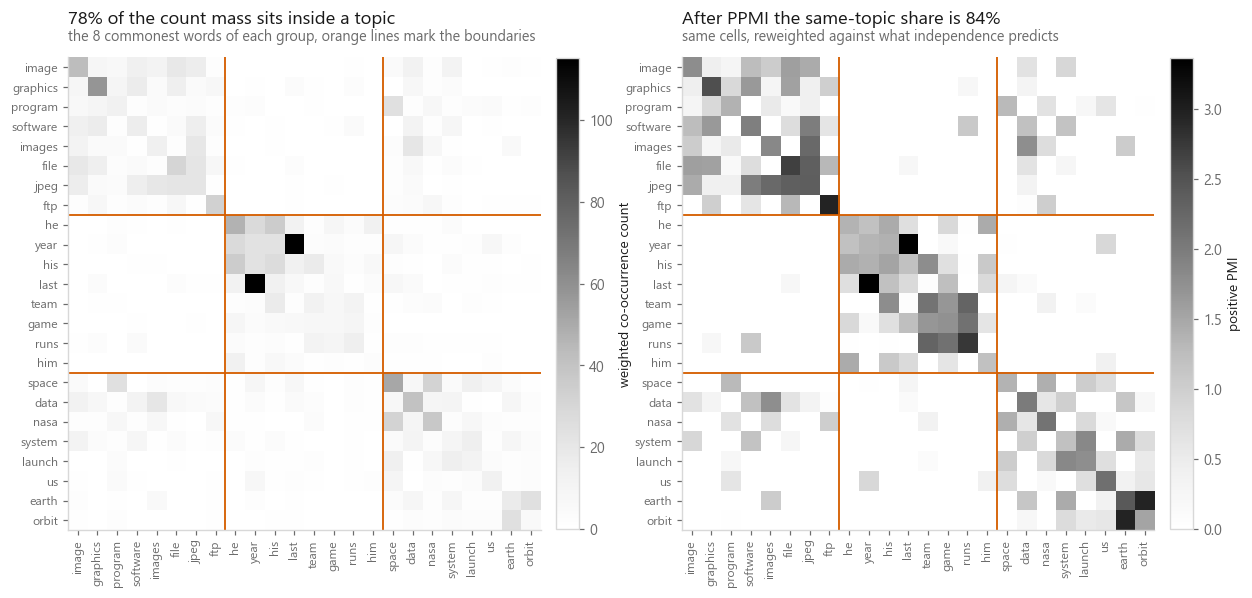

In [8]:
present = np.zeros((len(tokenised_train), V), dtype=bool)
for row, tokens in enumerate(tokenised_train):
    ids = [index_of[t] for t in set(tokens) if t in index_of]
    present[row, ids] = True

class_rate = np.stack([present[y_train == k].mean(axis=0) for k in range(len(LABELS))])
topic_of = class_rate.argmax(axis=0)
skew = class_rate.max(axis=0) / np.maximum(class_rate.sum(axis=0), 1e-12)
doc_freq = present.mean(axis=0)

PER_TOPIC = 8

picked, picked_topic = [], []
for k in range(len(LABELS)):
    candidates = np.flatnonzero((topic_of == k) & (skew >= 0.55) & (doc_freq >= 0.01))
    candidates = candidates[np.argsort(-freq[candidates])][:PER_TOPIC]
    picked.extend(candidates.tolist())
    picked_topic.extend([k] * len(candidates))
picked = np.array(picked)
picked_topic = np.array(picked_topic)

block_counts = X[picked][:, picked].toarray()
block_ppmi = M[picked][:, picked].toarray()
same_topic = picked_topic[:, None] == picked_topic[None, :]
boundaries = np.flatnonzero(np.diff(picked_topic)) + 0.5

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6))
labels_for_axis = [str(vocab[i]) for i in picked]

for ax, data, name in [(axes[0], block_counts, "weighted co-occurrence count"),
                       (axes[1], block_ppmi, "positive PMI")]:
    image = ax.imshow(data, cmap="Greys", aspect="equal", interpolation="nearest")
    ax.set_xticks(range(len(picked)), labels_for_axis, rotation=90, fontsize=8)
    ax.set_yticks(range(len(picked)), labels_for_axis, fontsize=8)
    ax.grid(False)
    for boundary in boundaries:
        ax.axhline(boundary, color=style.HIGHLIGHT, lw=1.2)
        ax.axvline(boundary, color=style.HIGHLIGHT, lw=1.2)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.03).set_label(name, fontsize=9)

share_counts = block_counts[same_topic].sum() / max(block_counts.sum(), 1e-12)
share_ppmi = block_ppmi[same_topic].sum() / max(block_ppmi.sum(), 1e-12)
style.title(axes[0],
            f"{share_counts:.0%} of the count mass sits inside a topic",
            f"the {PER_TOPIC} commonest words of each group, orange lines mark "
            f"the boundaries")
style.title(axes[1],
            f"After PPMI the same-topic share is {share_ppmi:.0%}",
            "same cells, reweighted against what independence predicts")

style.save(fig, FIG / "fig-01-cooccurrence.png")

print("words chosen, by topic:")
for k, name in enumerate(LABELS):
    print(f"  {name:<9}", ", ".join(vocab[picked[picked_topic == k]]))
print(f"\nsame-topic share of the mass: counts {share_counts:.1%}, "
      f"PPMI {share_ppmi:.1%}")

The three blocks along the diagonal are the topics. The two percentages in the
titles are the same quantity computed twice: what share of the total mass in the
picture falls inside a block rather than between blocks. Compare them and you
have the whole argument for reweighting counts, or the evidence against it on
this corpus.

That block structure is the entire signal an embedding has to work with. Every
method below is a different way of compressing it.

### Truncated SVD, the oldest embedding

`randomized_svd` is scikit-learn's workhorse for exactly this: a few dozen
singular vectors of a large sparse matrix, without forming anything dense.
Truncated SVDs are nested, so computing the top 128 once lets me read off every
smaller dimension by slicing.

In [9]:
from sklearn.utils.extmath import randomized_svd

DIM = 64
MAX_DIM = 128

started = time.perf_counter()
U, S, Vt = randomized_svd(M, n_components=MAX_DIM, n_iter=7, random_state=SEED)
svd_seconds = time.perf_counter() - started


def svd_embedding(d):
    """U_d * sqrt(Sigma_d). The square root splits the scale between the two sides."""
    return U[:, :d] * np.sqrt(S[:d])


E_svd = svd_embedding(DIM)

print(f"randomized SVD to {MAX_DIM} components in {svd_seconds:.1f} s")
print(f"largest singular value {S[0]:.2f}, {DIM}th {S[DIM - 1]:.2f}, "
      f"{MAX_DIM}th {S[-1]:.2f}")
print(f"embedding matrix: {E_svd.shape[0]:,} words x {E_svd.shape[1]} dimensions")

randomized SVD to 128 components in 0.8 s
largest singular value 417.73, 64th 65.46, 128th 55.29
embedding matrix: 3,000 words x 64 dimensions


### Skip-gram with negative sampling

Two pieces of machinery before the model. The first is the pair list.

Word2Vec does not use a fixed window. It draws the window size uniformly from
$1$ to $W$ for every centre word, which means a pair at offset $d$ survives with
probability $(W - d + 1) / W$. Nearer words are seen more often. That is the same
instinct as GloVe's $1/d$ weight, implemented by sampling instead of by
arithmetic, and I keep the two faithful to their own conventions so the
comparison later is between the objectives rather than between my shortcuts.

In [10]:
NEGATIVES = 5


def skipgram_pairs(documents, window=WINDOW, seed=SEED):
    """(centre, context) pairs with word2vec's dynamic window, both directions."""
    generator = np.random.default_rng(seed)
    centres, contexts = [], []
    for ids in documents:
        for offset in range(1, window + 1):
            if len(ids) <= offset:
                break
            keep = generator.random(len(ids) - offset) < (window - offset + 1) / window
            left, right = ids[:-offset][keep], ids[offset:][keep]
            centres.append(left);  contexts.append(right)
            centres.append(right); contexts.append(left)
    return np.concatenate(centres), np.concatenate(contexts)


centres, contexts = skipgram_pairs(id_docs)

# The noise table: word2vec's own trick. Fill an array with each word repeated in
# proportion to f^0.75, then a uniform draw from the array is a draw from P_n.
NOISE_TABLE_SIZE = 1_000_000
noise_weight = freq ** 0.75
noise_weight /= noise_weight.sum()
noise_table = np.repeat(np.arange(V),
                        np.maximum((noise_weight * NOISE_TABLE_SIZE).astype(np.int64), 1))

print(f"training pairs: {len(centres):,} "
      f"({len(centres) / stream_tokens:.1f} per surviving token)")
print(f"negatives per pair: {NEGATIVES}, so {len(centres) * (1 + NEGATIVES):,} "
      f"binary decisions per epoch")
print(f"noise table: {len(noise_table):,} entries")
example = np.argsort(-freq)[:5]
print("\nsampling probability, plain unigram against the 3/4 power:")
print(pd.DataFrame({
    "word": vocab[example],
    "unigram": (freq[example] / freq.sum()).round(4),
    "unigram^0.75": noise_weight[example].round(4),
}).to_string(index=False))

training pairs: 990,952 (5.9 per surviving token)
negatives per pair: 5, so 5,945,712 binary decisions per epoch
noise table: 998,599 entries

sampling probability, plain unigram against the 3/4 power:
word  unigram  unigram^0.75
 the   0.0613        0.0214
  to   0.0294        0.0123
 and   0.0267        0.0115
  of   0.0266        0.0114
  in   0.0186        0.0087


In [11]:
class SkipGramNS(nn.Module):
    """Two embedding tables and one dot product. That is the whole model."""

    def __init__(self, size, dim):
        super().__init__()
        self.centre = nn.Embedding(size, dim)
        self.context = nn.Embedding(size, dim)
        # word2vec's own initialisation: small random centres, zero contexts.
        nn.init.uniform_(self.centre.weight, -0.5 / dim, 0.5 / dim)
        nn.init.zeros_(self.context.weight)

    def forward(self, centre_ids, context_ids, negative_ids):
        v = self.centre(centre_ids)                       # (B, d)
        u_pos = self.context(context_ids)                 # (B, d)
        u_neg = self.context(negative_ids)                # (B, K, d)
        positive = (v * u_pos).sum(-1)                    # (B,)
        negative = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)   # (B, K)
        # One binary cross entropy per decision: real pairs up, sampled pairs down.
        return -(F.logsigmoid(positive) + F.logsigmoid(-negative).sum(1)).mean()


def train_skipgram(dim=DIM, epochs=10, batch=16384, lr=1e-2, seed=SEED):
    torch.manual_seed(seed)
    model = SkipGramNS(V, dim).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    generator = np.random.default_rng(seed + 1)

    centre_t = torch.from_numpy(centres.astype(np.int64))
    context_t = torch.from_numpy(contexts.astype(np.int64))
    curve = []

    for epoch in range(epochs):
        order = generator.permutation(len(centres))
        running, seen = 0.0, 0
        for start in range(0, len(order), batch):
            chunk = torch.from_numpy(order[start:start + batch])
            negatives = torch.from_numpy(
                noise_table[generator.integers(0, len(noise_table),
                                               size=(len(chunk), NEGATIVES))].astype(np.int64))
            optimiser.zero_grad()
            loss = model(centre_t[chunk], context_t[chunk], negatives)
            loss.backward()
            optimiser.step()
            running += float(loss) * len(chunk)
            seen += len(chunk)
        curve.append(running / seen)
    return model, curve


started = time.perf_counter()
sgns, sgns_curve = train_skipgram()
sgns_seconds = time.perf_counter() - started

E_sgns_centre = sgns.centre.weight.detach().cpu().numpy()
E_sgns_context = sgns.context.weight.detach().cpu().numpy()
E_sgns = E_sgns_centre

print(f"skip-gram trained in {sgns_seconds:.0f} s, {len(sgns_curve)} epochs")
print(f"loss, first epoch {sgns_curve[0]:.4f}  ->  last epoch {sgns_curve[-1]:.4f}")
print(f"a model that could not tell real pairs from fake ones would sit at "
      f"{-(np.log(0.5) * (1 + NEGATIVES)):.4f}")

C:\Users\pilot\AppData\Local\Temp\ipykernel_33504\3822471599.py:44: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  running += float(loss) * len(chunk)


skip-gram trained in 20 s, 10 epochs
loss, first epoch 2.9970  ->  last epoch 2.2189
a model that could not tell real pairs from fake ones would sit at 4.1589


That last line is the reference point for the loss. If every decision came out
at probability one half, the loss would be $(1 + K)\log 2$. Anything below it is
the model separating real pairs from invented ones.

### GloVe

The training set is the list of non-zero cells of $X$, which is why GloVe scales
with the number of distinct co-occurring pairs rather than with the length of
the corpus. AdaGrad is the optimiser the paper uses, and it suits this problem:
rare words appear in few cells and want large steps when they do.

In [12]:
X_MAX, ALPHA = 100.0, 0.75

coo = X.tocoo()
glove_i = torch.from_numpy(coo.row.astype(np.int64))
glove_j = torch.from_numpy(coo.col.astype(np.int64))
glove_x = torch.from_numpy(coo.data.astype(np.float32))
glove_logx = torch.log(glove_x)
glove_weight = torch.clamp((glove_x / X_MAX) ** ALPHA, max=1.0)


class GloVe(nn.Module):
    """Two vectors and two biases per word, fitted to log co-occurrence."""

    def __init__(self, size, dim):
        super().__init__()
        self.w = nn.Embedding(size, dim)
        self.w_context = nn.Embedding(size, dim)
        self.b = nn.Embedding(size, 1)
        self.b_context = nn.Embedding(size, 1)
        for table in (self.w, self.w_context):
            nn.init.uniform_(table.weight, -0.5 / dim, 0.5 / dim)
        for table in (self.b, self.b_context):
            nn.init.zeros_(table.weight)

    def forward(self, i, j):
        return ((self.w(i) * self.w_context(j)).sum(-1)
                + self.b(i).squeeze(-1) + self.b_context(j).squeeze(-1))


def train_glove(dim=DIM, epochs=60, batch=32768, lr=0.05, seed=SEED):
    torch.manual_seed(seed)
    model = GloVe(V, dim).to(device)
    optimiser = torch.optim.Adagrad(model.parameters(), lr=lr)
    generator = np.random.default_rng(seed + 2)
    curve = []

    for epoch in range(epochs):
        order = torch.from_numpy(generator.permutation(len(glove_x)))
        running, seen = 0.0, 0
        for start in range(0, len(order), batch):
            chunk = order[start:start + batch]
            optimiser.zero_grad()
            residual = model(glove_i[chunk], glove_j[chunk]) - glove_logx[chunk]
            loss = (glove_weight[chunk] * residual ** 2).mean()
            loss.backward()
            optimiser.step()
            running += float(loss) * len(chunk)
            seen += len(chunk)
        curve.append(running / seen)
    return model, curve


started = time.perf_counter()
glove, glove_curve = train_glove()
glove_seconds = time.perf_counter() - started

# The paper's own recommendation: add the two sets of vectors rather than pick one.
E_glove = (glove.w.weight.detach().cpu().numpy()
           + glove.w_context.weight.detach().cpu().numpy())

print(f"GloVe trained in {glove_seconds:.0f} s on {len(glove_x):,} non-zero cells")
print(f"weighted loss, first epoch {glove_curve[0]:.4f}  ->  "
      f"last epoch {glove_curve[-1]:.4f}")
print(f"cells given full weight (x >= {X_MAX:.0f}): "
      f"{float((glove_weight >= 1.0).float().mean()):.2%}")
print(f"cells given less than a tenth weight: "
      f"{float((glove_weight < 0.1).float().mean()):.2%}")

GloVe trained in 33 s on 762,951 non-zero cells
weighted loss, first epoch 0.0276  ->  last epoch 0.0059
cells given full weight (x >= 100): 0.00%
cells given less than a tenth weight: 97.45%


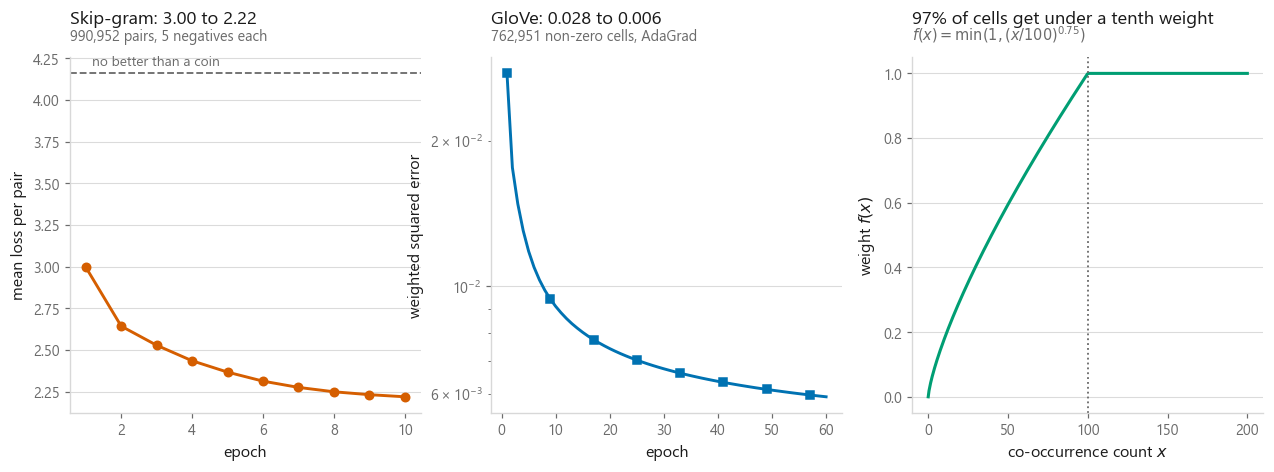

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2))

axes[0].plot(np.arange(1, len(sgns_curve) + 1), sgns_curve,
             color=style.HIGHLIGHT, marker=style.MARKERS[0])
axes[0].axhline(-(np.log(0.5) * (1 + NEGATIVES)), color=style.MUTED,
                linestyle="--", linewidth=1.2)
axes[0].annotate("no better than a coin", xy=(1, -(np.log(0.5) * (1 + NEGATIVES))),
                 xytext=(4, 5), textcoords="offset points",
                 fontsize=9, color=style.MUTED)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("mean loss per pair")
style.title(axes[0], f"Skip-gram: {sgns_curve[0]:.2f} to {sgns_curve[-1]:.2f}",
            f"{len(centres):,} pairs, {NEGATIVES} negatives each")

axes[1].plot(np.arange(1, len(glove_curve) + 1), glove_curve,
             color=style.PALETTE[0], marker=style.MARKERS[1], markevery=8)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted squared error")
style.title(axes[1], f"GloVe: {glove_curve[0]:.3f} to {glove_curve[-1]:.3f}",
            f"{len(glove_x):,} non-zero cells, AdaGrad")

grid = np.linspace(0, 200, 400)
axes[2].plot(grid, np.clip((grid / X_MAX) ** ALPHA, None, 1.0),
             color=style.PALETTE[2], linewidth=2.0)
axes[2].axvline(X_MAX, color=style.MUTED, linestyle=":", linewidth=1.2)
axes[2].set_xlabel("co-occurrence count $x$")
axes[2].set_ylabel("weight $f(x)$")
style.title(axes[2],
            f"{float((glove_weight < 0.1).float().mean()):.0%} of cells get "
            f"under a tenth weight",
            f"$f(x) = \\min(1, (x/{X_MAX:.0f})^{{{ALPHA}}})$")

style.save(fig, FIG / "fig-02-training.png")

The two losses are not comparable to each other, and putting them side by side
is not an invitation to compare them. One is a mean binary cross entropy per
sampled pair; the other is a weighted squared error on log counts. They are here
so you can see that both objectives are being minimised, and that GloVe's
weighting function is doing what the third panel says: most cells in the matrix
are small counts, and most cells are therefore nearly ignored.

## 4. Is skip-gram really factorising a PMI matrix?

Section 2 quoted the result: at the optimum, and with enough dimensions,
skip-gram's two vectors satisfy $u_c^\top v_w = \mathrm{PMI}(w, c) - \log K$.
The model above has 64 dimensions for 3,000 words and ran for ten epochs, so it
is nowhere near the setting the theorem describes. The question is whether the
relation shows up anyway.

I take the cells of $X$ with enough mass for PMI to be worth computing, read the
trained model's dot product for those pairs, and plot one against the other.

In [14]:
# Keep the heaviest twentieth of the non-zero cells, with a floor, so the sample
# is defined by the corpus rather than by a threshold I picked to make it look good.
coo_all = X.tocoo()
MIN_CELL = max(2.0, float(np.quantile(coo_all.data, 0.95)))
strong = coo_all.data >= MIN_CELL
rows_s, cols_s = coo_all.row[strong], coo_all.col[strong]
total_mass = float(X.sum())
margin = np.asarray(X.sum(axis=1)).ravel().astype(np.float64)
pmi_strong = np.log(coo_all.data[strong].astype(np.float64) * total_mass
                    / (margin[rows_s] * margin[cols_s]))
shifted = pmi_strong - np.log(NEGATIVES)

dots = (E_sgns_centre[rows_s] * E_sgns_context[cols_s]).sum(axis=1)

sample = np.random.default_rng(SEED).choice(len(dots), size=min(6000, len(dots)),
                                            replace=False)
pearson = float(np.corrcoef(shifted[sample], dots[sample])[0, 1])
from scipy.stats import spearmanr
spearman = float(spearmanr(shifted[sample], dots[sample]).statistic)
slope, intercept = np.polyfit(shifted[sample], dots[sample], 1)

print(f"cells with weight >= {MIN_CELL:.2f}: {strong.sum():,} of {X.nnz:,}")
print(f"Pearson correlation, skip-gram dot against shifted PMI : {pearson:.3f}")
print(f"Spearman correlation                                   : {spearman:.3f}")
print(f"least-squares fit: dot = {slope:.3f} x (PMI - log K) + {intercept:.3f}")
print(f"theory at the optimum with unlimited dimensions: slope 1, intercept 0")

cells with weight >= 3.00: 39,392 of 762,951
Pearson correlation, skip-gram dot against shifted PMI : 0.832
Spearman correlation                                   : 0.790
least-squares fit: dot = 0.798 x (PMI - log K) + -0.305
theory at the optimum with unlimited dimensions: slope 1, intercept 0


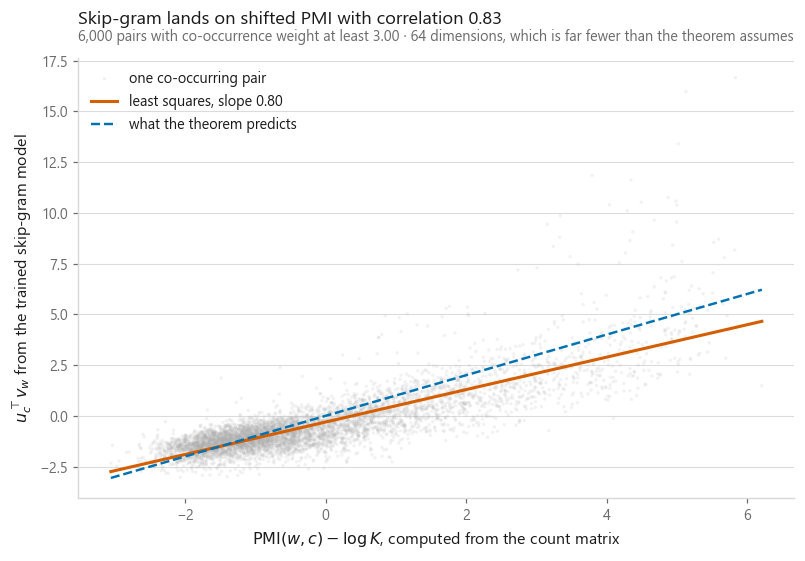

In [15]:
fig, ax = plt.subplots(figsize=(8.4, 5.2))

ax.scatter(shifted[sample], dots[sample], s=5, alpha=0.16,
           color=style.NEUTRAL, edgecolors="none", label="one co-occurring pair")
line = np.linspace(shifted[sample].min(), shifted[sample].max(), 50)
ax.plot(line, slope * line + intercept, color=style.HIGHLIGHT, linewidth=2.0,
        label=f"least squares, slope {slope:.2f}")
ax.plot(line, line, color=style.PALETTE[0], linestyle="--", linewidth=1.6,
        label="what the theorem predicts")
ax.set_xlabel(r"$\mathrm{PMI}(w, c) - \log K$, computed from the count matrix")
ax.set_ylabel(r"$u_c^\top v_w$ from the trained skip-gram model")
ax.legend()
style.title(ax,
            f"Skip-gram lands on shifted PMI with correlation {pearson:.2f}",
            f"{len(sample):,} pairs with co-occurrence weight at least "
            f"{MIN_CELL:.2f} · {DIM} dimensions, which is far fewer than the "
            f"theorem assumes")
style.save(fig, FIG / "fig-03-sgns-is-factorisation.png")

Read the printed correlation and the fitted slope before reading the cloud. The
dashed line is what would happen if the theorem applied exactly; the solid line
is what the model actually did. If the fitted slope comes out below one, that is
what a dimension budget too small to fit the matrix looks like: the model cannot
reproduce the extremes, so it shrinks everything towards the middle, which is
the shrinkage any rank-limited least squares fit produces.

The point of the figure is not the fit quality. It is that a model which never
computed a count, never formed a matrix, and never saw the letters P, M or I has
arranged its dot products along a PMI axis. All three methods in this notebook
are factorising the same table. They differ in the loss they use and in what
they do about the zeros.

## 5. Which one learned more

### A scoring task that does not depend on my taste

Nearest-neighbour lists are the standard way to eyeball embeddings, and eyeballing
is exactly the problem. I want a number, and I want it defined by the corpus
rather than by which neighbours I find charming.

The three newsgroups give me one. For every word I already computed the share of
each group's documents containing it. A word is **topical** if its distribution
across the three groups is lopsided enough and it appears in enough documents at
all. Every topical word gets the label of the group it leans towards, and the
score is: of a word's $k$ nearest neighbours among the topical words, what share
carry the same label?

The baseline is not one third, because the three groups contribute different
numbers of topical words, so I compute it exactly and print it. Nothing here
looked at an embedding, which is what makes it a fair scoreboard for all three.

In [16]:
SKEW_MIN, DOC_FREQ_MIN = 0.55, 0.01

topical = np.flatnonzero((skew >= SKEW_MIN) & (doc_freq >= DOC_FREQ_MIN))
topical_topic = topic_of[topical]
group_sizes = np.bincount(topical_topic, minlength=len(LABELS))
chance = float(np.mean((group_sizes[topical_topic] - 1) / (len(topical) - 1)))


def unit_rows(matrix):
    return matrix / np.maximum(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-12)


def neighbour_purity(embedding, k=10):
    """Share of a topical word's k nearest topical neighbours sharing its topic."""
    E = unit_rows(embedding[topical])
    similarity = E @ E.T
    np.fill_diagonal(similarity, -np.inf)
    nearest = np.argsort(-similarity, axis=1)[:, :k]
    return float((topical_topic[nearest] == topical_topic[:, None]).mean())


print(f"topical words: {len(topical):,} of {V:,} "
      f"(skew >= {SKEW_MIN}, in at least {DOC_FREQ_MIN:.0%} of documents)")
print(f"per group: {dict(zip(LABELS, group_sizes.tolist()))}")
print(f"chance purity for this set: {chance:.3f}\n")

METHODS = {"PPMI + SVD": E_svd, "skip-gram": E_sgns, "GloVe": E_glove}
K_GRID = [1, 3, 5, 10, 20]

purity = {name: [neighbour_purity(E, k) for k in K_GRID] for name, E in METHODS.items()}
table = pd.DataFrame(purity, index=[f"k={k}" for k in K_GRID]).T
print(table.round(3).to_string())

best_method = max(METHODS, key=lambda name: purity[name][K_GRID.index(10)])
print(f"\nhighest purity at k=10: {best_method} "
      f"({purity[best_method][K_GRID.index(10)]:.3f} against chance {chance:.3f})")

topical words: 681 of 3,000 (skew >= 0.55, in at least 1% of documents)
per group: {'graphics': 154, 'baseball': 184, 'space': 343}
chance purity for this set: 0.377

              k=1    k=3    k=5   k=10   k=20
PPMI + SVD  0.909  0.893  0.895  0.882  0.857
skip-gram   0.893  0.884  0.870  0.856  0.827
GloVe       0.720  0.673  0.660  0.617  0.572

highest purity at k=10: PPMI + SVD (0.882 against chance 0.377)


PPMI + SVD, purity at k=10 by rank:
 components  purity
          2   0.722
          4   0.922
          8   0.916
         16   0.906
         32   0.899
         64   0.882
        128   0.859


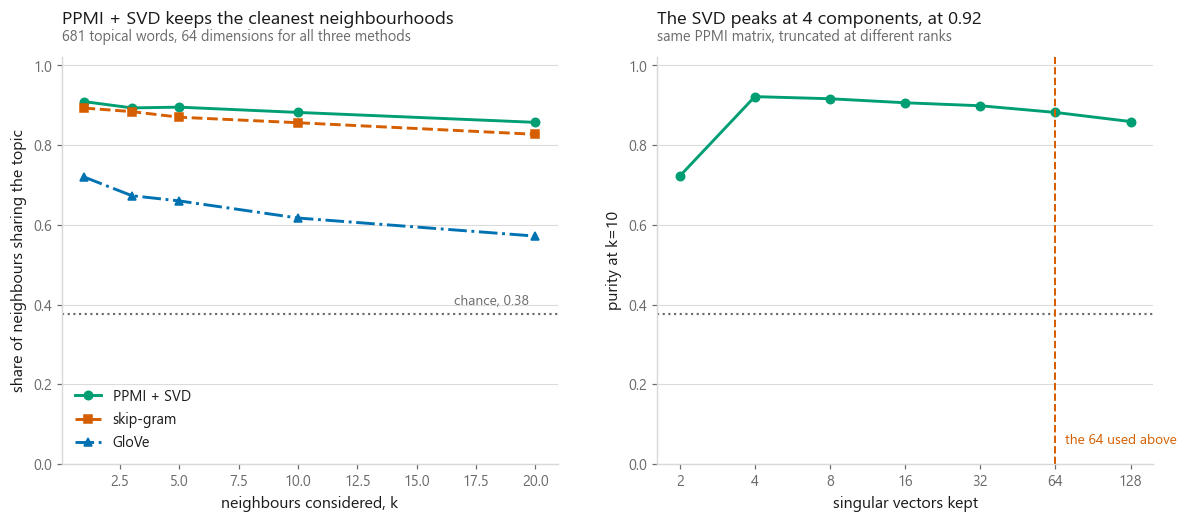

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

colours = {"PPMI + SVD": style.PALETTE[2], "skip-gram": style.HIGHLIGHT,
           "GloVe": style.PALETTE[0]}
for i, (name, scores) in enumerate(purity.items()):
    axes[0].plot(K_GRID, scores, marker=style.MARKERS[i], color=colours[name],
                 linestyle=style.DASHES[i], label=name)
axes[0].axhline(chance, color=style.MUTED, linestyle=":", linewidth=1.4)
axes[0].annotate(f"chance, {chance:.2f}", xy=(K_GRID[-1], chance),
                 xytext=(-4, 6), textcoords="offset points", ha="right",
                 fontsize=9, color=style.MUTED)
axes[0].set_xlabel("neighbours considered, k")
axes[0].set_ylabel("share of neighbours sharing the topic")
axes[0].set_ylim(0, 1.02)
axes[0].legend()
style.title(axes[0],
            f"{best_method} keeps the cleanest neighbourhoods",
            f"{len(topical):,} topical words, {DIM} dimensions for all three methods")

dims = [2, 4, 8, 16, 32, 64, 128]
svd_by_dim = [neighbour_purity(svd_embedding(d), 10) for d in dims]
axes[1].plot(dims, svd_by_dim, marker=style.MARKERS[0], color=style.PALETTE[2])
axes[1].axhline(chance, color=style.MUTED, linestyle=":", linewidth=1.4)
axes[1].axvline(DIM, color=style.HIGHLIGHT, linestyle="--", linewidth=1.3)
axes[1].annotate(f"the {DIM} used above", xy=(DIM, 0.05), xytext=(6, 0),
                 textcoords="offset points", fontsize=9, color=style.HIGHLIGHT)
axes[1].set_xscale("log", base=2)
axes[1].minorticks_off()
axes[1].set_xticks(dims, [str(d) for d in dims])
axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel("singular vectors kept")
axes[1].set_ylabel("purity at k=10")
best_dim = dims[int(np.argmax(svd_by_dim))]
style.title(axes[1],
            f"The SVD peaks at {best_dim} components, at {max(svd_by_dim):.2f}",
            "same PPMI matrix, truncated at different ranks")

style.save(fig, FIG / "fig-04-neighbour-purity.png")

print("PPMI + SVD, purity at k=10 by rank:")
print(pd.DataFrame({"components": dims, "purity": np.round(svd_by_dim, 3)})
      .to_string(index=False))

The right panel is worth as much as the left. Two failures pull against each
other as the rank changes: with too few components, words from different topics
are forced to share directions, and with too many, the trailing singular vectors
are fitting counts that occurred twice. The printed column says where the
balance fell on this corpus. Whatever rank it names is corpus-specific, which is
the argument for treating dimension as something to sweep rather than something
to copy from a paper fitted on text thousands of times larger.

### Neighbours, looked at directly

The number is the scoreboard. The lists are how you find out what the number is
measuring.

In [18]:
def neighbours(embedding, word, n=6):
    if word not in index_of:
        return ["(not in vocabulary)"]
    E = unit_rows(embedding)
    similarity = E @ E[index_of[word]]
    similarity[index_of[word]] = -np.inf
    return [f"{vocab[i]} {similarity[i]:.2f}" for i in np.argsort(-similarity)[:n]]


probe_words = [w for w in ["orbit", "pitcher", "image", "nasa", "season", "colour",
                           "launch", "hit", "graphics"] if w in index_of][:5]

for word in probe_words:
    print(f"\n{word}")
    for name, E in METHODS.items():
        print(f"  {name:<11} " + " | ".join(neighbours(E, word)))


orbit
  PPMI + SVD  earth 0.74 | moon 0.71 | planet 0.65 | circular 0.62 | km 0.61 | jupiter 0.60
  skip-gram   polar 0.69 | earth 0.68 | flyby 0.65 | circular 0.65 | inclination 0.65 | flybys 0.64
  GloVe       earth 0.66 | into 0.63 | polar 0.57 | moon 0.57 | low 0.53 | lunar 0.51

pitcher
  PPMI + SVD  cub 0.87 | hou 0.83 | snf 0.83 | atl 0.83 | phi 0.82 | cin 0.82
  skip-gram   cub 0.69 | snf 0.65 | cin 0.64 | martinez 0.64 | phi 0.60 | slaught 0.60
  GloVe       cub 0.56 | atl 0.54 | phi 0.48 | flybys 0.43 | word 0.42 | mon 0.42

image
  PPMI + SVD  manipulation 0.72 | processing 0.71 | images 0.69 | display 0.68 | functions 0.67 | color 0.65
  skip-gram   manipulation 0.71 | processing 0.70 | pict 0.63 | smoothing 0.62 | color 0.62 | jpeg 0.60
  GloVe       processing 0.70 | analysis 0.58 | manipulation 0.58 | display 0.58 | package 0.57 | format 0.56

nasa
  PPMI + SVD  ames 0.77 | spacelink 0.75 | gov 0.75 | jpl 0.74 | jsc 0.73 | larc 0.71
  skip-gram   ames 0.77 | gov 0.75 | 

### Analogies, and how many of them actually work

The famous demonstration is $v_{\text{king}} - v_{\text{man}} + v_{\text{woman}}$
landing near $v_{\text{queen}}$. It is a real property of vectors trained on
enough text and it is also the single most oversold result in the field, because
it is shown once, on the pair it works for, and never scored.

So I score it. Three families of analogy, each written down before any embedding
was consulted:

The **plural** family is generated from singular and plural pairs, every ordered
combination of two pairs giving one question. The **past tense** family works the
same way. The **semantic** family is hand-written and is the one the published
vectors are famous for.

Every question is filtered to the four words being in the vocabulary, the count
that survives is printed, and the standard rule is used: compute
$v_b - v_a + v_c$, exclude $a$, $b$ and $c$ from the candidates, and take the
nearest vector by cosine.

In [19]:
PLURALS = [("year", "years"), ("day", "days"), ("time", "times"), ("game", "games"),
           ("image", "images"), ("file", "files"), ("point", "points"),
           ("team", "teams"), ("player", "players"), ("number", "numbers"),
           ("line", "lines"), ("week", "weeks"), ("problem", "problems"),
           ("question", "questions"), ("program", "programs"), ("system", "systems"),
           ("run", "runs"), ("hit", "hits"), ("thing", "things"), ("year", "years")]

PAST = [("play", "played"), ("work", "worked"), ("use", "used"), ("call", "called"),
        ("look", "looked"), ("start", "started"), ("want", "wanted"),
        ("need", "needed"), ("ask", "asked"), ("post", "posted"),
        ("seem", "seemed"), ("happen", "happened")]

SEMANTIC = [("man", "woman", "he", "she"), ("he", "his", "she", "her"),
            ("man", "men", "woman", "women"), ("good", "better", "bad", "worse"),
            ("big", "bigger", "small", "smaller"),
            ("fast", "faster", "slow", "slower"),
            ("first", "second", "third", "fourth"),
            ("one", "two", "three", "four"),
            ("pitcher", "baseball", "pixel", "graphics"),
            ("earth", "orbit", "team", "league"),
            ("nasa", "space", "league", "baseball"),
            ("king", "queen", "man", "woman")]


def build_quads(pairs, cap=40, seed=SEED):
    """Every ordered combination of two inflection pairs, capped and shuffled."""
    unique = sorted(set(pairs))
    quads = [(a, b, c, d) for a, b in unique for c, d in unique if (a, b) != (c, d)]
    generator = np.random.default_rng(seed)
    generator.shuffle(quads)
    return quads[:cap]


FAMILIES = {"plural": build_quads(PLURALS),
            "past tense": build_quads(PAST),
            "semantic": SEMANTIC}

in_vocab = {name: [q for q in quads if all(w in index_of for w in q)]
            for name, quads in FAMILIES.items()}

for name, quads in FAMILIES.items():
    kept = in_vocab[name]
    print(f"{name:<11} {len(kept):>3} of {len(quads):>3} questions have all four "
          f"words in the vocabulary")
missing = sorted({w for q in SEMANTIC for w in q if w not in index_of})
print(f"\nsemantic words missing from the vocabulary: {missing}")


def analogy_hits(embedding, quads, topn=5):
    """Top-1 and top-5 hit rate, plus the top-3 guesses for each question."""
    E = unit_rows(embedding)
    hits1 = hits5 = 0
    detail = []
    for a, b, c, d in quads:
        ia, ib, ic, target = (index_of[a], index_of[b], index_of[c], index_of[d])
        query = E[ib] - E[ia] + E[ic]
        query /= max(np.linalg.norm(query), 1e-12)
        similarity = E @ query
        similarity[[ia, ib, ic]] = -np.inf
        ranked = np.argsort(-similarity)[:topn]
        hits1 += int(ranked[0] == target)
        hits5 += int(target in ranked)
        detail.append((f"{a}:{b} :: {c}:?", d, [vocab[i] for i in ranked[:3]]))
    n = max(len(quads), 1)
    return hits1 / n, hits5 / n, detail


rows, details = [], {}
for name, quads in in_vocab.items():
    for method, E in METHODS.items():
        top1, top5, detail = analogy_hits(E, quads)
        rows.append({"family": name, "method": method, "questions": len(quads),
                     "top-1": round(top1, 3), "top-5": round(top5, 3)})
        details[(name, method)] = detail

analogies = pd.DataFrame(rows)
print(analogies.to_string(index=False))

overall = analogies.groupby("method")[["top-1", "top-5"]].mean().round(3)
print("\naveraged over the three families:")
print(overall.to_string())

plural       40 of  40 questions have all four words in the vocabulary
past tense   40 of  40 questions have all four words in the vocabulary
semantic      8 of  12 questions have all four words in the vocabulary

semantic words missing from the vocabulary: ['queen', 'slower', 'woman']
    family     method  questions  top-1  top-5
    plural PPMI + SVD         40  0.025  0.350
    plural  skip-gram         40  0.025  0.125
    plural      GloVe         40  0.050  0.250
past tense PPMI + SVD         40  0.025  0.075
past tense  skip-gram         40  0.050  0.100
past tense      GloVe         40  0.000  0.000
  semantic PPMI + SVD          8  0.125  0.375
  semantic  skip-gram          8  0.000  0.125
  semantic      GloVe          8  0.000  0.125

averaged over the three families:
            top-1  top-5
method                  
GloVe       0.017  0.125
PPMI + SVD  0.058  0.267
skip-gram   0.025  0.117


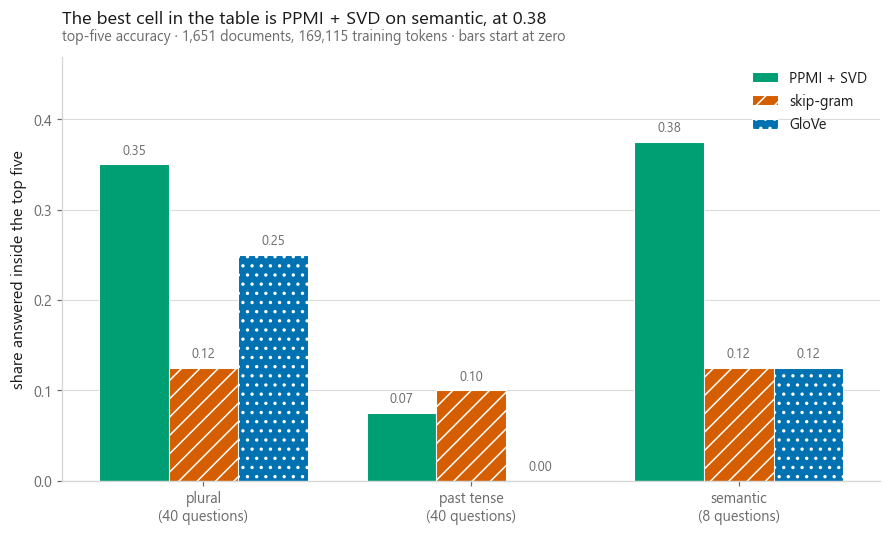

In [20]:
fig, ax = plt.subplots(figsize=(9.6, 5.0))

families = list(in_vocab)
methods = list(METHODS)
width = 0.26
positions = np.arange(len(families))

HATCHES = ["", "//", ".."]     # a second channel so colour is not carrying it alone

for i, method in enumerate(methods):
    values = [analogies[(analogies["family"] == f) & (analogies["method"] == method)]
              ["top-5"].iloc[0] for f in families]
    bars = ax.bar(positions + (i - 1) * width, values, width=width,
                  color=colours[method], label=method,
                  hatch=HATCHES[i], edgecolor="white")
    for rect, value in zip(bars, values):
        ax.text(rect.get_x() + rect.get_width() / 2, value + 0.008, f"{value:.2f}",
                ha="center", va="bottom", fontsize=8.5, color=style.MUTED)

ax.set_xticks(positions, [f"{f}\n({len(in_vocab[f])} questions)" for f in families])
ax.set_ylabel("share answered inside the top five")
ax.set_ylim(0, max(0.25, analogies["top-5"].max() * 1.25))
ax.legend()
best_family = analogies.loc[analogies["top-5"].idxmax()]
style.title(ax,
            f"The best cell in the table is {best_family['method']} on "
            f"{best_family['family']}, at {best_family['top-5']:.2f}",
            f"top-five accuracy · {len(docs_train):,} documents, "
            f"{stream_tokens:,} training tokens · bars start at zero")
style.save(fig, FIG / "fig-05-analogies.png")

### The failures, printed

A hit rate hides what the model actually said. Here are the first questions of
each family with the best method's top three guesses beside the answer, so you
can see the kind of mistake being made.

In [21]:
for name in in_vocab:
    detail = details[(name, best_method)]
    if not detail:
        continue
    print(f"\n{name}, guesses from {best_method}:")
    shown = pd.DataFrame([{"question": q, "answer": a,
                           "top three": ", ".join(g),
                           "hit": "yes" if a == g[0] else ""}
                          for q, a, g in detail[:8]])
    print(shown.to_string(index=False))


plural, guesses from PPMI + SVD:
                    question    answer                top three hit
       point:points :: run:?      runs     fourth, score, ninth    
    image:images :: system:?   systems orbiting, thermal, earth    
     team:teams :: problem:?  problems  understand, there, find    
         game:games :: hit:?      hits      totals, rbi, murphy    
question:questions :: line:?     lines    containing, list, faq    
    time:times :: question:? questions  expensive, favor, given    
question:questions :: file:?     files      usenet, jfif, files    
         file:files :: day:?      days    fans, night, watching    

past tense, guesses from PPMI + SVD:
                 question   answer                    top three hit
    call:called :: look:?   looked          example, very, this    
   work:worked :: start:?  started          thread, ten, couple    
     need:needed :: use:?     used changes, standards, provides    
        use:used :: ask:?    asked     liter

The table above is the honest version of the king-and-queen demonstration. Read
the guesses rather than the hit column: a wrong answer that is a word of the
right kind means the geometry is roughly correct and the corpus is too small to
pin down which neighbour is meant, while a wrong answer from an unrelated topic
means the offset vector carried no usable direction at all.

There is a structural reason to expect the inflection families to do better than
the semantic one, and it has nothing to do with meaning. `year` and `years`
appear in nearly identical contexts, so their difference is a small consistent
vector that many pairs share. `king` and `queen` differ in contexts that this
corpus barely contains. The printed table says whether that expectation survived.

### When these vectors lose: a classifier on top

The last measurement puts the embeddings back where 09-01 left off. Represent a
document as the mean of its word vectors, fit the same logistic regression on
the same three groups, and score it against the TF-IDF matrix from the previous
notebook.

The mean of a document's word vectors throws away order, which the bag of words
already did, and also throws away emphasis, which the bag of words did not: a
word appearing six times moves the mean exactly as far as six different words
appearing once. It is the crudest possible document vector and it is what
everyone reaches for first.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


def document_vectors(documents, embedding):
    E = unit_rows(embedding)
    out = np.zeros((len(documents), embedding.shape[1]), dtype=np.float64)
    empty = 0
    for row, text in enumerate(documents):
        ids = [index_of[t] for t in tokenise(text) if t in index_of]
        if ids:
            out[row] = E[ids].mean(axis=0)
        else:
            empty += 1
    return out, empty


records = []
tfidf = TfidfVectorizer(stop_words="english", min_df=2)
X_tr = tfidf.fit_transform(docs_train)
X_te = tfidf.transform(docs_test)
model = LogisticRegression(max_iter=2000, random_state=SEED).fit(X_tr, y_train)
records.append({"features": f"TF-IDF, {X_tr.shape[1]:,} columns",
                "width": X_tr.shape[1],
                "accuracy": accuracy_score(y_test, model.predict(X_te))})

for name, E in METHODS.items():
    D_tr, empty_tr = document_vectors(docs_train, E)
    D_te, empty_te = document_vectors(docs_test, E)
    model = LogisticRegression(max_iter=3000, random_state=SEED).fit(D_tr, y_train)
    records.append({"features": f"mean {name} vector, {DIM} columns",
                    "width": DIM,
                    "accuracy": accuracy_score(y_test, model.predict(D_te))})

downstream = pd.DataFrame(records).sort_values("accuracy", ascending=False)
print(downstream.round(4).to_string(index=False))

winner = downstream.iloc[0]
loser = downstream.iloc[-1]
print(f"\nbest : {winner['features']} at {winner['accuracy']:.4f}")
print(f"worst: {loser['features']} at {loser['accuracy']:.4f}")
print(f"documents with no in-vocabulary token: {empty_te} of {len(docs_test):,} test")

                          features  width  accuracy
            TF-IDF, 10,396 columns  10396    0.9233
 mean skip-gram vector, 64 columns     64    0.8922
mean PPMI + SVD vector, 64 columns     64    0.8804
     mean GloVe vector, 64 columns     64    0.8201

best : TF-IDF, 10,396 columns at 0.9233
worst: mean GloVe vector, 64 columns at 0.8201
documents with no in-vocabulary token: 0 of 1,095 test


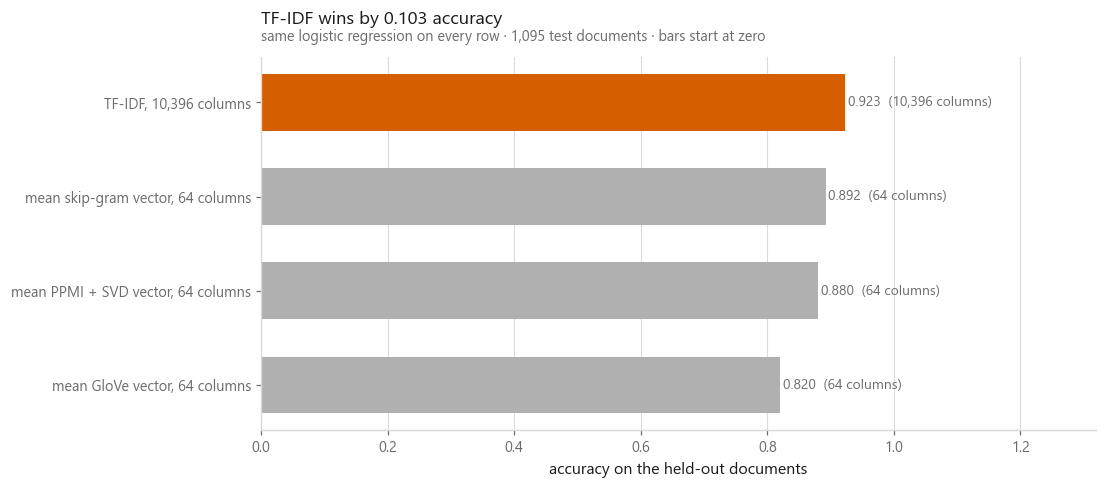

In [23]:
fig, ax = plt.subplots(figsize=(9.8, 4.4))

order = downstream.iloc[::-1]
bar_colours = [style.HIGHLIGHT if i == len(order) - 1 else style.NEUTRAL
               for i in range(len(order))]
bars = ax.barh(range(len(order)), order["accuracy"], color=bar_colours, height=0.6)
for rect, value, width_col in zip(bars, order["accuracy"], order["width"]):
    ax.text(value + 0.004, rect.get_y() + rect.get_height() / 2,
            f"{value:.3f}  ({width_col:,} columns)", va="center",
            fontsize=9, color=style.MUTED)
ax.set_yticks(range(len(order)), order["features"])
ax.set_xlim(0, 1.32)
ax.set_xlabel("accuracy on the held-out documents")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(ax,
            f"{winner['features'].split(',')[0]} wins by "
            f"{winner['accuracy'] - loser['accuracy']:.3f} accuracy",
            f"same logistic regression on every row · {len(docs_test):,} test "
            f"documents · bars start at zero")
style.save(fig, FIG / "fig-06-downstream.png")

Read the printed table. Whatever the ranking, the width column is the thing to
notice: one representation uses thousands of columns and the others use
sixty-four, and any accuracy the wide one gives up per column it is spending on
memorising which exact words belong to which group.

This is the case where embeddings have the least to offer. Topic classification
rewards knowing which words appeared, which is what a sparse count matrix
encodes perfectly. Averaging vectors destroys precisely that. Embeddings earn
their place when the model has to generalise to words it did not see enough of,
when the sequence order matters, or when the vectors were trained on a corpus
orders of magnitude larger than the labelled task, which is the situation
everyone is actually in when they download pretrained vectors.

Which is the honest summary of this whole notebook. The methods are right, the
implementations agree with their published objectives, and the corpus is too
small for the results everyone quotes. That gap is worth seeing once, from the
inside, before you use somebody else's vectors and assume the numbers came free.

### What gensim would add

In practice nobody writes these two loops. `gensim` is the standard library for
it and is not installed for this notebook, so everything above is the from-scratch
version and the only library call is scikit-learn's `randomized_svd`. What gensim
gives you beyond the code here: a multithreaded C implementation, the CBOW variant
that predicts a centre word from its context instead of the reverse, hierarchical
softmax as an alternative to negative sampling, automatic phrase detection so
`new_york` becomes one token, and loaders for the pretrained vectors that make
the analogy results in section 5 look completely different.

## Cheat sheet

| | |
|---|---|
| **The assumption** | A word is characterised by the words around it. Every method here is a compression of one co-occurrence table |
| **PPMI** | $\max\!\left(0, \log \frac{X_{ij} X_{\cdot\cdot}}{X_{i\cdot} X_{\cdot j}}\right)$. The count-based answer to what TF-IDF answered for documents |
| **SVD embedding** | $U_d \Sigma_d^{1/2}$ of the PPMI matrix. No training loop, and competitive on a small corpus |
| **Skip-gram** | $-\log\sigma(u_c^\top v_w) - \sum_k \log\sigma(-u_{n_k}^\top v_w)$. Streams the corpus, never builds a matrix |
| **Negative sampling** | Draw $K$ fake contexts from $f^{3/4}$. The exponent is empirical, and it favours rare words |
| **Subsampling** | Discard frequent tokens with probability $1 - (\sqrt{t/f} + t/f)$. It changes the vectors more than most hyperparameters do |
| **GloVe** | $\sum f(X_{ij})(w_i^\top \tilde w_j + b_i + \tilde b_j - \log X_{ij})^2$, over non-zero cells only. The biases absorb the marginals |
| **$f(x)$** | $\min(1, (x/100)^{3/4})$. Caps the huge cells and nearly ignores the tiny ones |
| **The connection** | Skip-gram's optimum is $\mathrm{PMI} - \log K$. All three methods factorise the same table |
| **Two vectors per word** | Centre and context. GloVe recommends adding them; word2vec conventionally keeps the centre ones |
| **Scoring** | Define a task from your own corpus and print the number. Nearest-neighbour lists are for diagnosing, not for deciding |
| **Corpus size** | Analogies need a corpus far larger than this one. Measure before you quote the demonstration |
| **Next** | [Recurrent networks](../03-recurrent-neural-networks/), which read these vectors in order instead of averaging them |

## What to remember

1. Every word embedding in this notebook is a low-rank factorisation of a
   co-occurrence table. Skip-gram is the one that hides it, and section 4 shows
   it doing it anyway.
2. PPMI plus a truncated SVD is a real embedding method and takes one linear
   algebra call. The purity table says how it did against the two trained
   models, and a count-based method is not automatically the loser.
3. Skip-gram's loss is binary classification against sampled noise, which is what
   lets it avoid ever normalising over the vocabulary.
4. GloVe's weighting function is the part of the method that matters most and
   gets discussed least. Most cells of the matrix are small counts, and it nearly
   ignores them.
5. Subsampling frequent words is preprocessing, not tuning, and it changes the
   resulting vectors more than the choice between the two objectives does.
6. Score embeddings with a task defined by your corpus and print the number.
   Nearest-neighbour lists will make anything look good if you pick the query.
7. Score the analogies instead of showing the one that works. The printed table
   says how many resolved on this corpus and the failure list says what the
   model answered instead. The demonstration everyone quotes is as much a
   property of the corpus as of the method.
8. Averaging word vectors into a document vector throws away word counts, which
   is exactly what topic classification wanted. Check it against TF-IDF before
   assuming the newer representation wins.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [09-03 Recurrent neural networks](../03-recurrent-neural-networks/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#NLP` `#WordEmbeddings` `#Word2Vec` `#GloVe`
`#PyTorch` `#Python` `#DataScience` `#MLTutorial` `#DeepLearning`